<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/02_experiment_timm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
  from torchinfo import summary
  import timm
except ModuleNotFoundError as e:
  !pip3 install -q torchinfo
  !pip3 install -q timm
  import timm
  from torchinfo import summary

import torch
from torch import nn
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt


## Loading Pretrained Model `timm`

In [2]:
device = torch.device("cuda" if torch.cuda.is_available()\
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")

device

device(type='cpu')

In [3]:
model_0 = timm.create_model("adv_inception_v3",
                            pretrained=True,
                            num_classes=56,
                            cache_dir="./models/")

model_0.eval()

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name adv_inception_v3 to current inception_v3.tf_adv_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [4]:
model_0.training # evaluation mode is turned on

False

In [5]:
model_0.num_classes

56

In [6]:
for name, param in model_0.named_parameters():
  print(name, param.shape)

Conv2d_1a_3x3.conv.weight torch.Size([32, 3, 3, 3])
Conv2d_1a_3x3.bn.weight torch.Size([32])
Conv2d_1a_3x3.bn.bias torch.Size([32])
Conv2d_2a_3x3.conv.weight torch.Size([32, 32, 3, 3])
Conv2d_2a_3x3.bn.weight torch.Size([32])
Conv2d_2a_3x3.bn.bias torch.Size([32])
Conv2d_2b_3x3.conv.weight torch.Size([64, 32, 3, 3])
Conv2d_2b_3x3.bn.weight torch.Size([64])
Conv2d_2b_3x3.bn.bias torch.Size([64])
Conv2d_3b_1x1.conv.weight torch.Size([80, 64, 1, 1])
Conv2d_3b_1x1.bn.weight torch.Size([80])
Conv2d_3b_1x1.bn.bias torch.Size([80])
Conv2d_4a_3x3.conv.weight torch.Size([192, 80, 3, 3])
Conv2d_4a_3x3.bn.weight torch.Size([192])
Conv2d_4a_3x3.bn.bias torch.Size([192])
Mixed_5b.branch1x1.conv.weight torch.Size([64, 192, 1, 1])
Mixed_5b.branch1x1.bn.weight torch.Size([64])
Mixed_5b.branch1x1.bn.bias torch.Size([64])
Mixed_5b.branch5x5_1.conv.weight torch.Size([48, 192, 1, 1])
Mixed_5b.branch5x5_1.bn.weight torch.Size([48])
Mixed_5b.branch5x5_1.bn.bias torch.Size([48])
Mixed_5b.branch5x5_2.conv.wei

In [7]:
# trainable parameters
sum([p.numel() for p in model_0.parameters() if p.requires_grad == True])

21900312

In [8]:
for name, param in model_0.named_parameters():
  if "fc" in name:
    param.requires_grad_(True)
  else:
    param.requires_grad_(False)

In [9]:
# total parameters
sum([p.numel() for p in model_0.parameters()])

21900312

In [10]:
# trainable parameters
sum([p.numel() for p in model_0.parameters() if p.requires_grad == True])

114744

In [11]:
summary(model_0,
        (1,3,224,224),
        col_names=["input_size", "output_size"])

Layer (type:depth-idx)                   Input Shape               Output Shape
InceptionV3                              [1, 3, 224, 224]          [1, 56]
├─ConvNormAct: 1-1                       [1, 3, 224, 224]          [1, 32, 111, 111]
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 32, 111, 111]
│    └─BatchNormAct2d: 2-2               [1, 32, 111, 111]         [1, 32, 111, 111]
│    │    └─Identity: 3-1                [1, 32, 111, 111]         [1, 32, 111, 111]
│    │    └─ReLU: 3-2                    [1, 32, 111, 111]         [1, 32, 111, 111]
├─ConvNormAct: 1-2                       [1, 32, 111, 111]         [1, 32, 109, 109]
│    └─Conv2d: 2-3                       [1, 32, 111, 111]         [1, 32, 109, 109]
│    └─BatchNormAct2d: 2-4               [1, 32, 109, 109]         [1, 32, 109, 109]
│    │    └─Identity: 3-3                [1, 32, 109, 109]         [1, 32, 109, 109]
│    │    └─ReLU: 3-4                    [1, 32, 109, 109]         [1, 32, 109, 

## Visualizing Feature Maps

In [12]:
def cosine_sim(x, y):
  return (x @ y)/(len(x) @ len(y))

In [13]:
from numpy import dot
from numpy.linalg import norm

def cosine_sim(x,y):
  return dot(x,y) / (norm(x)*norm(y))

# a = torch.randn(3, 2)
# b = torch.randn(3, 2)

# cosine_sim(a,b)

In [14]:
def cosine_sim(x, y):
  cos = nn.CosineSimilarity()
  return cos(x,y)

a = torch.randn(3, 2)
b = torch.randn(3, 2)

cosine_sim(a,b)

tensor([-0.4893, -0.1600,  0.2965])

In [15]:
import requests

url = "http://craphound.com/images/1006884_2adf8fc7.jpg"

response = requests.get(url)
if response == 200:
  with open("./random_images/", "wb") as f:
    f.write(response.content)
  print("Downloaded...")

In [16]:
import requests
from pathlib import Path

CAT_DIR = Path("./cat_data")
CAT_DIR.mkdir(parents=True, exist_ok=True)

cat_image_url = "https://i.guim.co.uk/img/media/327aa3f0c3b8e40ab03b4ae80319064e401c6fbc/377_133_3542_2834/master/3542.jpg?width=1200&height=1200&quality=85&auto=format&fit=crop&s=34d32522f47e4a67286f9894fc81c863"

response = requests.get(cat_image_url, stream=True)

if response.status_code == 200:
  with open("./cat_data/cat_image.jpg", "wb") as f:
    for chunk in response.iter_content(1024):
      f.write(chunk)
  print("Downloaded...")
else:
  print("Failed")

Downloaded...


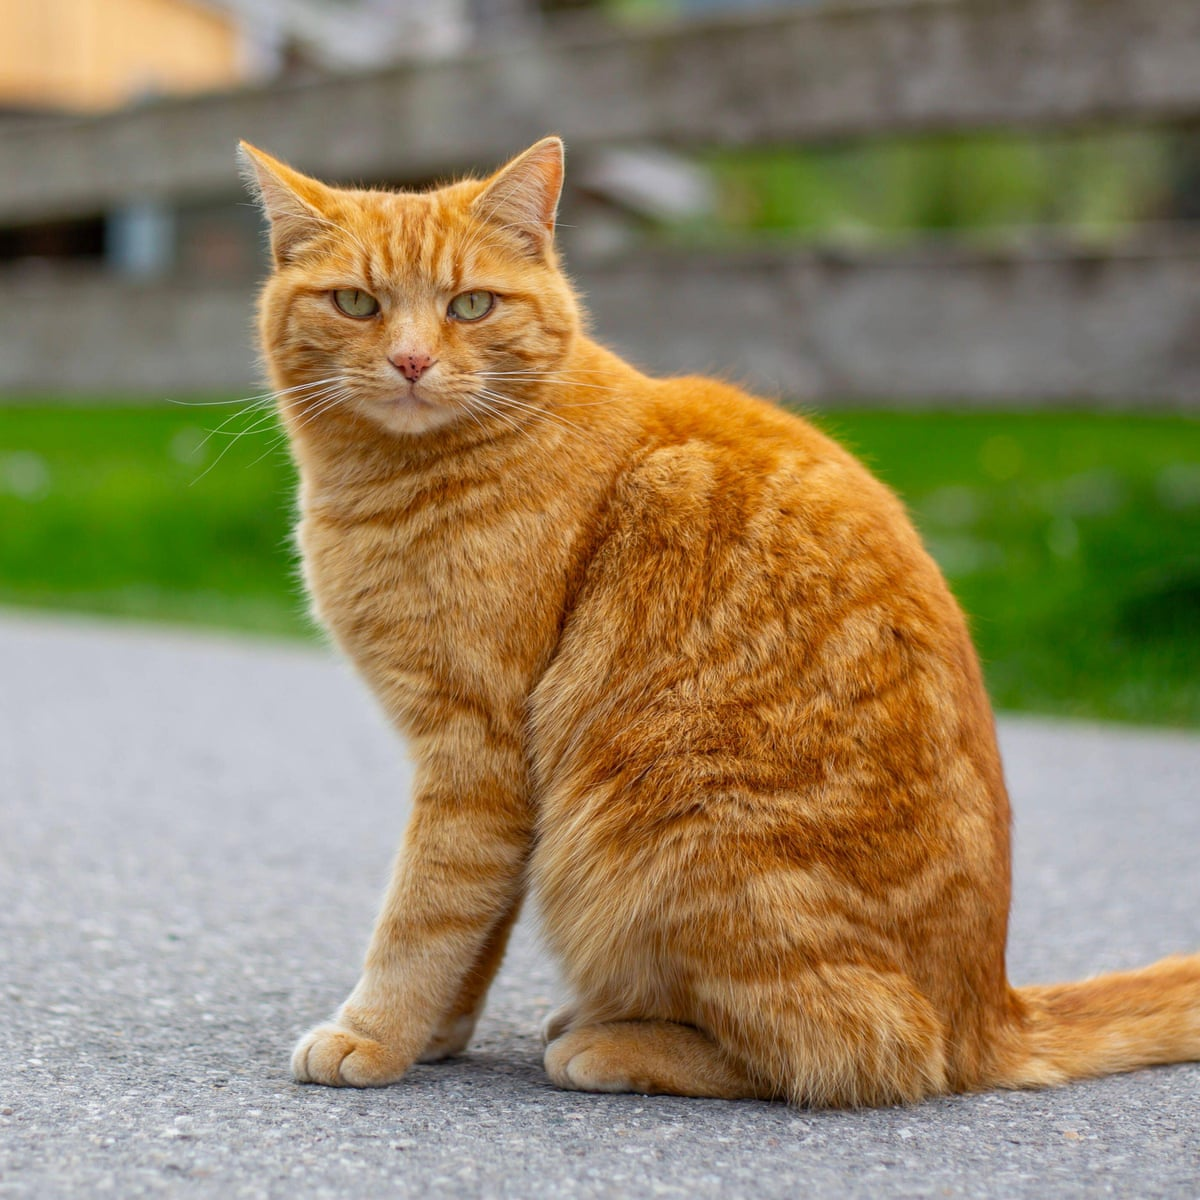

1200 1200


In [17]:
cat_image_path = "./cat_data/cat_image.jpg"

type(cat_image_path)

cat_image = Image.open(cat_image_path)

display(cat_image)
print(cat_image.height, cat_image.width)

In [18]:
type(cat_image)

PIL.JpegImagePlugin.JpegImageFile

In [19]:
cat_image_np = np.asarray(cat_image)

cat_image_np.shape

(1200, 1200, 3)

In [20]:
cat_image_np[0].max(), cat_image_np[1].max(), cat_image_np[2].max()

(np.uint8(246), np.uint8(246), np.uint8(246))

In [21]:
cat_image_np[0].min(), cat_image_np[1].min(), cat_image_np[2].min()

(np.uint8(18), np.uint8(18), np.uint8(18))

In [22]:
maxpool_nn = nn.Sequential(
    nn.MaxPool2d(kernel_size=5, padding=1, stride=1, dilation=5)#,
    # nn.MaxPool2d(kernel_size=4, padding=1, stride=1),
    # nn.MaxPool2d(kernel_size=5, padding=1, stride=1),
    # nn.MaxPool2d(kernel_size=6, padding=1, stride=1),
    #nn.MaxPool2d(kernel_size=20, padding=1, stride=1)
)

m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))

m.shape

/tmp/ipython-input-2832368790.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))


torch.Size([3, 1182, 1182])

(np.float64(-0.5), np.float64(1181.5), np.float64(1181.5), np.float64(-0.5))

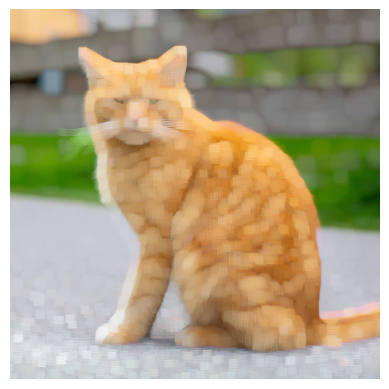

In [23]:
plt.imshow(m.permute(2,1,0))
plt.axis(False)

torch.Size([3, 111, 111])


(np.float64(-0.5), np.float64(110.5), np.float64(110.5), np.float64(-0.5))

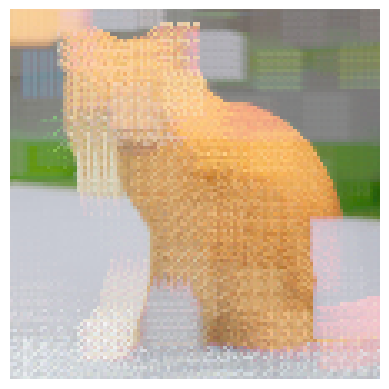

In [24]:
maxpool_nn = nn.Sequential(
    nn.MaxPool2d(kernel_size=5, padding=1, stride=10, dilation=25)
)

m = maxpool_nn(torch.from_numpy(cat_image_np).permute(2,1,0))

print(m.shape)

plt.imshow(m.permute(2,1,0))
plt.axis(False)

In [25]:
cat_image_np.shape, torch.from_numpy(cat_image_np).dtype

((1200, 1200, 3), torch.uint8)

In [26]:
torch.tensor(torch.from_numpy(cat_image_np,), dtype=torch.float32).dtype

/tmp/ipython-input-3439097745.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(torch.from_numpy(cat_image_np,), dtype=torch.float32).dtype


torch.float32

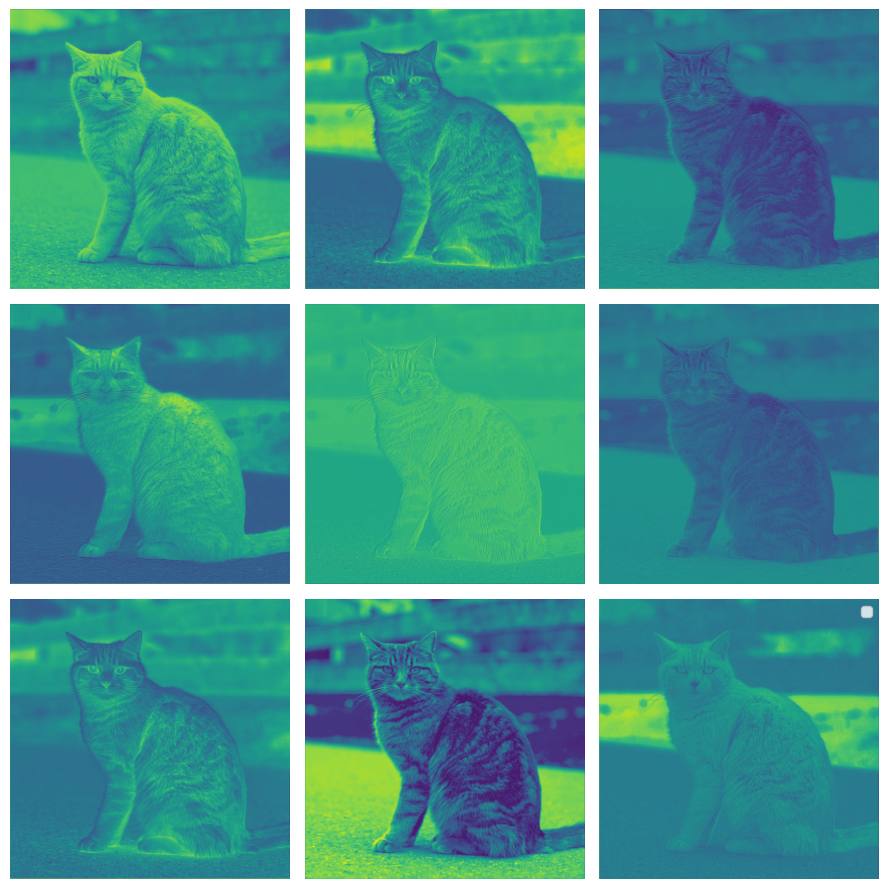

In [27]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Conv2d(in_channels=3,
                            out_channels=9,
                            kernel_size=3,
                            stride=1,
                            padding=1,
                            dilation=1)

f = feature_maps_nn(torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float))

n_maps = f.shape[0]

cols = math.ceil(math.sqrt(n_maps))
rows = math.ceil(n_maps/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()

for i in range(n_maps):
  axes[i].imshow(f[i].permute(1,0).detach().numpy())
  axes[i].axis("off")

for i in range(n_maps, len(axes)):
  axes[i].axis("off")

plt.legend()
plt.tight_layout()
plt.show()

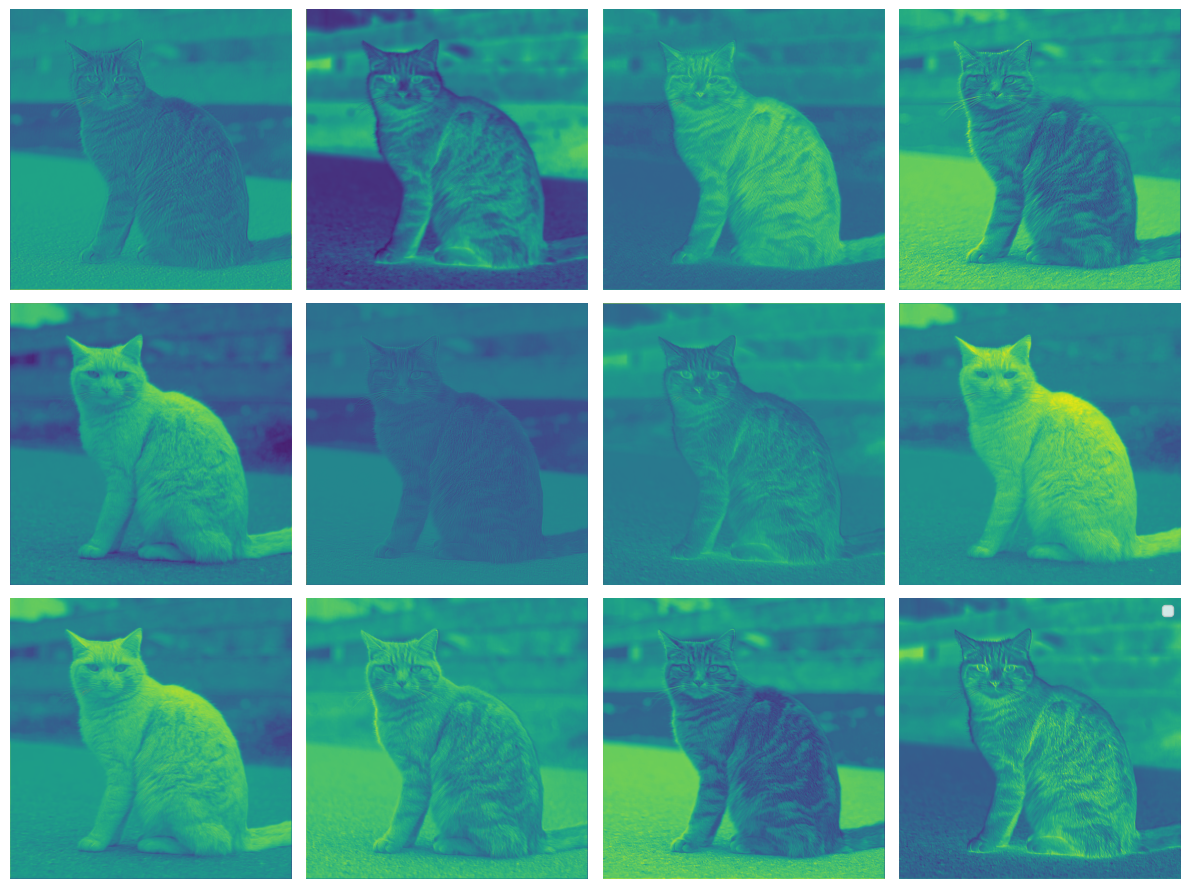

In [144]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Sequential(
    nn.Conv2d(in_channels=3,
              out_channels=10,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=10,
              out_channels=40,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=40,
              out_channels=12,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=2),

)

f = feature_maps_nn(torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float))

n_maps = f.shape[0]

cols = math.ceil(math.sqrt(n_maps))
rows = math.ceil(n_maps/cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()

for i in range(n_maps):
  axes[i].imshow(f[i].permute(1,0).detach().numpy())
  axes[i].axis("off")

for i in range(n_maps, len(axes)):
  axes[i].axis("off")

plt.legend()
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1197.5), np.float64(1197.5), np.float64(-0.5))

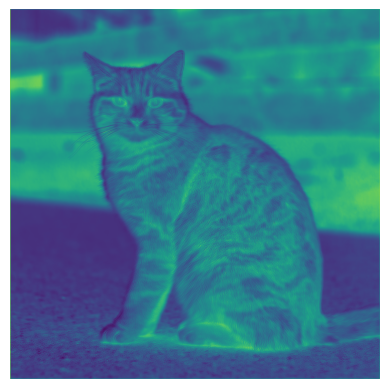

In [145]:
plt.imshow(f[1].permute(1,0).detach().numpy())
plt.axis(False)

(np.float64(-0.5), np.float64(1197.5), np.float64(1197.5), np.float64(-0.5))

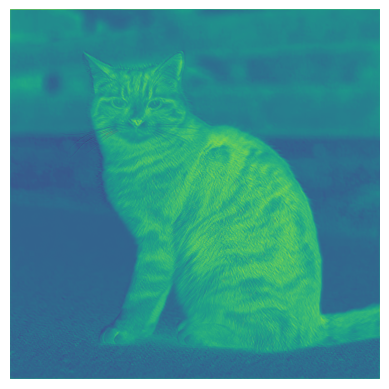

In [146]:
plt.imshow(f[2].permute(1,0).detach().numpy())
plt.axis(False)

In [156]:
import torch.nn.functional as F

print(f"\nConv output shape: {f[1].shape, f[2].shape}")

f1 = f[1].unsqueeze(0).detach().cpu()
f2 = f[2].unsqueeze(0).detach().cpu()

print(f"\nUnsqueeze(0) output shape: f1={f1.shape}, f2={f2.shape}")

f1 = f1.flatten(start_dim=1)
f2 = f2.flatten(start_dim=1)

print(f"\nFlattening output shape: {f1.shape, f2.shape}")

f1_norm = F.normalize(f1, p=2, dim=1)
f2_norm = F.normalize(f2, p=2, dim=1)

cos = torch.mm(f1_norm, f2_norm.T)

print(f"\nCosine Similarity: {cos.item():.4f}, Shape: {cos.shape}\n")


Conv output shape: (torch.Size([1198, 1198]), torch.Size([1198, 1198]))

Unsqueeze(0) output shape: f1=torch.Size([1, 1198, 1198]), f2=torch.Size([1, 1198, 1198])

Flattening output shape: (torch.Size([1, 1435204]), torch.Size([1, 1435204]))

Cosine Similarity: 0.6163, Shape: torch.Size([1, 1])



In [117]:
import torch.nn.functional as F

a = torch.arange(10.0, 20.0).reshape(5,2)

a, a.shape, a.min(), a.max()

(tensor([[10., 11.],
         [12., 13.],
         [14., 15.],
         [16., 17.],
         [18., 19.]]),
 torch.Size([5, 2]),
 tensor(10.),
 tensor(19.))

In [118]:
a = F.normalize(a)

a, a.shape, a.min(), a.max()

(tensor([[0.6727, 0.7399],
         [0.6783, 0.7348],
         [0.6823, 0.7311],
         [0.6854, 0.7282],
         [0.6877, 0.7260]]),
 torch.Size([5, 2]),
 tensor(0.6727),
 tensor(0.7399))

## Cosine Similarity of Feature Maps

In [119]:
def consine_sim(input: torch.Tensor):
  input = input.detach().numpy()

  return np.dot(input[1], input[2]) / (np.linalg.norm(input[1]) * np.linalg.norm(input[2]))

In [120]:
# single scalar value for cosine similarity
f1 = f[1].detach().numpy().flatten()
f2 = f[2].detach().numpy().flatten()

cos_sim = np.dot(a=f1, b=f2) / (np.linalg.norm(f1) * np.linalg.norm(f2))

cos_sim

np.float32(-0.7829594)

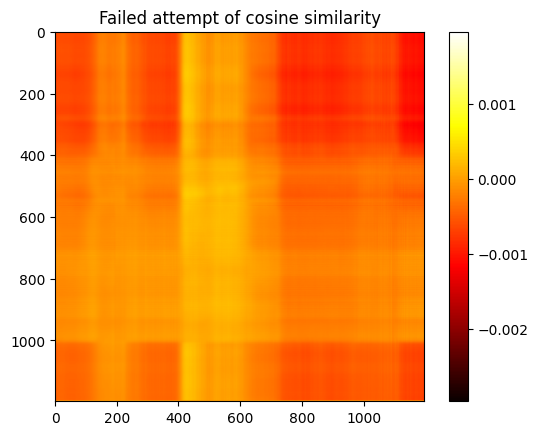

In [121]:
# heatmap
f1 = f[1].detach().numpy()
f2 = f[2].detach().numpy()

epsilon = 1e-6 # helps to avoid zero division
cos_sim = np.dot(f1, f2) / (np.linalg.norm(f1) * np.linalg.norm(f2) + epsilon)

plt.imshow(cos_sim, cmap="hot")
plt.title("Failed attempt of cosine similarity")
plt.colorbar()
plt.show()


Conv output shape: torch.Size([9, 1198, 1198])

Squeeze() output shape: torch.Size([9, 1198, 1198])

Shape after flattening: torch.Size([9, 1435204])

Stats BEFORE normalization: min=-85.1175, max=95.5435, std=35.5701

Stats AFTER normalization: min=-0.0018, max=0.0024, std=0.0008

Cosine similarity shape: torch.Size([9, 9])



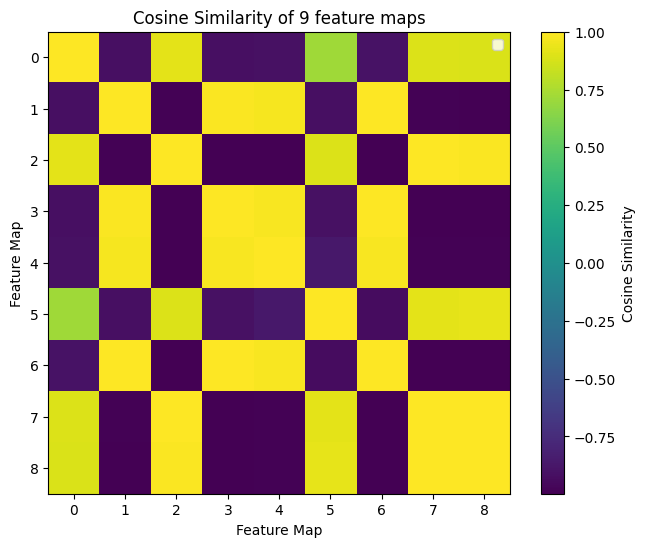

In [143]:
import math
import warnings

warnings.filterwarnings("ignore")

feature_maps_nn = nn.Sequential(
    nn.Conv2d(in_channels=3,
              out_channels=10,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=10,
              out_channels=40,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=1),
    nn.Conv2d(in_channels=40,
              out_channels=9,
              kernel_size=3,
              stride=1,
              padding=1,
              dilation=2),

)

img = torch.tensor(torch.from_numpy(cat_image_np).permute(2,1,0), dtype=torch.float)
f = feature_maps_nn(img)
print(f"\nConv output shape: {f.shape}")
f = f.squeeze(0)
print(f"\nSqueeze() output shape: {f.shape}")

n_maps = f.shape[0]

f_flat = f.view(n_maps, -1)
print(f"\nShape after flattening: {f_flat.shape}")

print(f"\nStats BEFORE normalization: min={f_flat.min():.4f}, max={f_flat.max():.4f}, std={f_flat.std():.4f}")
f_norm = F.normalize(f_flat, p=2, dim=1)
print(f"\nStats AFTER normalization: min={f_norm.min():.4f}, max={f_norm.max():.4f}, std={f_norm.std():.4f}")

cos_sim = torch.mm(f_norm, f_norm.T)

print(f"\nCosine similarity shape: {cos_sim.shape}\n") # 1.0: identical - 0.0: unrelated, -1.0:opposite activation

plt.figure(figsize=(8,6))
plt.imshow(cos_sim.detach().numpy(), cmap="viridis")
plt.colorbar(label="Cosine Similarity")
plt.title(f"Cosine Similarity of {f.shape[0]} feature maps")
plt.xlabel("Feature Map")
plt.ylabel("Feature Map")
plt.legend()
#plt.axis("off")
plt.show()
